# Skeleton-of-Thought

1. **Skeleton Stage**：拆解問題的主要框架或骨架。
2. **Point-expanding Stage**：進一步擴展每個骨架的具體細節。
將前一日的新聞資料依據 Skeleton Stage 拆解的每個判斷依據都做一次判斷隔日漲跌  
e.g. 20230104的新聞判斷漲跌後存在20230105  
儲存格式：  
20230105  
判斷依據1: 由20230104的新聞判斷為漲  
判斷依據2: 由20230104的新聞判斷為跌  
...  


檔案說明：  
存在 out_twii/sot  


In [1]:
import os
import textwrap
import math
import pandas as pd
import numpy as np
from collections import Counter
from datetime import datetime
from dateutil.relativedelta import relativedelta
from IPython.display import display
from IPython.display import Markdown

from langchain_openai import ChatOpenAI


def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))


llm = ChatOpenAI(
  openai_api_key = os.getenv('OPENAI_API_KEY'),
  model='gpt-4o-mini',
  temperature=1,
)

# 買進賣出需要的手續費
fee = {
  'tax_stock' : 0.003,
  'tax_future' : 0.00002 * 2, # 買進與賣出各0.00002
  'fee_stock' : 0.001425 * 2, # 買進與賣出各0.001425
  'fee_future' : 0.00002 * 2, # 個家不大相同，以交易稅計算
  'sliding_price' : 0.00001, # 0.03%
}

stock_id = "AAPL"
path_out = "out_stock/GA_sot_4omini/"

# Skeleton Stage
建立 factors

In [2]:
import json

factors = {}

path_factors = f"{path_out}{stock_id}/factors.json"
print(path_factors)
with open(path_factors, "r") as f:
  factors = json.load(f)

# Access by index using list of keys
key_list = list(factors.keys())
value_list = list(factors.values())
print(key_list)
print(len(key_list))
print(len(value_list))

out_stock/GA_sot_4omini/AAPL/factors.json
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30']
30
30


# Point-expanding Stage

In [5]:
import time
import os
import json
import pandas as pd
from datetime import datetime, timedelta

def point_expanting(st, et, stock_id, skeleton):
    path_price_his = f"{os.path.dirname(os.path.abspath(os.getcwd()))}/history_data/us/stock_price/{stock_id}.csv"

    # 讀取CSV檔案
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')
    df_price_his = df_price_his[(st <= df_price_his['Date']) & (df_price_his['Date'] <= et)]

    # batch_size = 500
    output_data = {}  # 使用字典來存儲每一天的輸出數據

    for i in range(len(df_price_his)):
        # 取得前一日日期和新聞標題
        news_date = df_price_his.iloc[i]['Date'] - timedelta(days=1)
        text_news = "今日的新聞標題"

        path_news_file = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/us/news_title/" + stock_id + "news_title.json"
        with open(path_news_file, 'r', encoding='utf-8') as f:
            news_data = json.load(f)
            text_news += f"{news_data[news_date.strftime('%Y%m%d')]} \n"
        # print(text_news)

        batch = []
        for factor in value_list:
            messages = [
("system", "You are an expert in the financial field and will answer users' questions about stock day trading."),
("human",
f"""
This is the news headline: {text_news}
If it aligns with what {factor} represents as positive news, answer "yes." If it is negative news, answer "no." If it is indeterminate, answer "unknown."

Respond in the following format. You only need to give a single judgment based on all the news headlines:
Judgment: #yes/#no/#unknown. Try to avoid answering "unknown."
Reason: Provide a **very brief** explanation in 1-2 sentences!
""")
                ]
            batch.append(messages)
        res = llm.batch(batch)

        date_str = df_price_his.iloc[i]['Date'].strftime('%Y%m%d')
        skeleton_res = {}
        for i in range(len(res)):
            sig = 0
            sig_str = res[i].content.split("Reason")[0]
            if "unknown" in sig_str:
                sig = 0
            elif "yes" in sig_str:
                sig = 1
            elif "no" in sig_str:
                sig = -1

            skeleton_res[key_list[i]] = {
                "response" : res[i].content,
                "sig" : sig,
                "token": res[i].usage_metadata
            }
        
        output_data[date_str] = {
            "skeleton": skeleton_res,
        }

    # 將所有輸出數據寫入到同一個dictioanry中
    data = {
        "model": llm.model_name,
        "temperature": llm.temperature,
        "stock_id": stock_id,
        "output_data": output_data,
    }
    
    return data

In [6]:
def save_data(folder_path, data):
    count = 1
    while True:
        if os.path.exists(folder_path + str(count) + ".json"):
            count += 1
            continue
        else:
            out_file = folder_path + str(count) + ".json"
            break
    json_content = json.dumps(data, ensure_ascii=False, indent=4)
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    with open(out_file, "w", encoding="UTF-8") as f:
        f.write(json_content)
    print(f"已儲存至{out_file}")

## generate content

In [8]:
st = datetime(2023, 7, 1)
et = datetime(2024, 9, 30)
path_expand = f"{path_out}{stock_id}/expand"

print("running... , will save to ", path_expand)
data = point_expanting(st, et, stock_id, factors)
save_data(path_expand, data)


running... , will save to  out_stock/GA_sot_4omini/MSFT/expand
已儲存至out_stock/GA_sot_4omini/MSFT/expand1.json


合併兩段不同日期的檔案

In [ ]:
def merge_data(path1, path2):
    with open(path1, 'r', encoding='utf-8') as f:
        data1 = json.load(f)
    with open(path2, 'r', encoding='utf-8') as f:
        data2 = json.load(f)
    
    data1['output_data'].update(data2['output_data'])
    return data1

# 輸出合併後的檔案
data3 = merge_data(path_out + '4.json', path_out + '3.json')
save_data(path_out, data3)


# GA

## 評分

In [3]:
import pandas as pd
import json
import os

def eval(individual, stock_id, data):
    # print(data)
    # 計算準確率和平均報酬率
    gain = []
    loss = []
    gain_precision = []
    loss_precision = []

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    ttl_count = 0

    path_price_his = f"{os.path.dirname(os.path.abspath(os.getcwd()))}/history_data/us/stock_price/{stock_id}.csv"
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')

    for date_str, value in data.items():
        ttl_count += 1
        # print(date_str)
        # print(value)
        
        sigs = []
        sig = 0
        for i in range(len(individual)):

            if individual[i] == 1:
                # print(value['skeleton'][f'E{str(i+1)}']['sig'])
                sigs.append(value['skeleton'][f'{str(i+1)}']['sig'])

            
        # 移除 sig 為 0 的元素
        sigs = list(filter(lambda a: a != 0, sigs))

        if len(sigs) > 0:
            # Count the frequency of each element
            count = Counter(sigs)

            # Get the maximum frequency
            max_count = max(count.values())

            # Get all elements with the maximum frequency
            most_frequent = [k for k, v in count.items() if v == max_count]

            # If there is a tie, set sig to 0; otherwise, set it to the most frequent element
            if len(most_frequent) > 1:
                sig = 0
            else:
                sig = most_frequent[0]

        df_price = df_price_his[df_price_his['Date'] == pd.to_datetime(date_str, format='%Y%m%d')]

        if df_price.empty:
            continue

        rtn = (float(df_price.iloc[0]['Close']) - float(df_price.iloc[0]['Open']))  / float(df_price.iloc[0]['Open']) 

        if pd.isna(rtn):
            rtn = 0

        if sig > 0:
            if rtn > 0:
                tp += 1
                gain.append(rtn)
                gain_precision.append(rtn)
            else:
                fp += 1
                loss.append(rtn)
                loss_precision.append(rtn)
        elif sig == -1:
            if rtn < 0:
                tn += 1
                gain.append(-rtn)
            else:
                fn += 1
                loss.append(-rtn)

    accuracy = 0
    precision = 0
    recall = 0
    ev = 0
    if tp + fp + tn + fn == 0 or tp + fp == 0 or tp + fn == 0:
        accuracy = 0
        precision = 0
        recall = 0
        ev = 0
        precision_ev = 0
    elif len(gain) == 0 or len(loss) == 0:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = 0
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = (sum(gain) / len(gain))*accuracy + (sum(loss) / len(loss))*(1-accuracy)
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    result = {
        'tp' : tp,
        'fp' : fp,
        'tn' : tn,
        'fn' : fn,
        'avail_count' : tp + fp + tn + fn,
        'ttl_count' : ttl_count,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'ev': ev,
        'precision_ev' : precision_ev,
    }

    return result

## GA Training
遺傳演算法

In [8]:
import json
import random
from datetime import datetime


# setting --------------------------------
start_day = datetime(2023, 10, 1)
end_day = datetime(2024, 6, 30)
mode = 1     # 0: 準確率, 1: 期望值
# ----------------------------------------

path_str = "exp"
if mode == 0:
    path_str = path_str + "_ac"
else:
    path_str = path_str + "_ev"

out_folder = f"{path_out}/{stock_id}/{start_day.strftime('%Y%m%d')}_{end_day.strftime('%Y%m%d')}" + f"{path_str}"
count = 1
while True:
    if os.path.exists(out_folder + str(count)):
        count += 1
        continue
    else:
        out_folder = out_folder + str(count)
        break

state_file= out_folder + '/state.json'
results_file= out_folder + '/generation_results.json'

ask_count = 0
individual_score = {}
# 讀取日期範圍內的資料
with open(f"{path_out}{stock_id}/expand1.json", 'r') as f:
    content = f.read().strip()
    data_points = json.loads(content)
data_in_datarange = {}
for date_str, value in data_points["output_data"].items():
    date = datetime.strptime(date_str, '%Y%m%d')
    if start_day <= date <= end_day:
        data_in_datarange[date_str] = value
print(len(data_in_datarange))
print(data_in_datarange.keys())

187
dict_keys(['20240628', '20240627', '20240626', '20240625', '20240624', '20240621', '20240620', '20240618', '20240617', '20240614', '20240613', '20240612', '20240611', '20240610', '20240607', '20240606', '20240605', '20240604', '20240603', '20240531', '20240530', '20240529', '20240528', '20240524', '20240523', '20240522', '20240521', '20240520', '20240517', '20240516', '20240515', '20240514', '20240513', '20240510', '20240509', '20240508', '20240507', '20240506', '20240503', '20240502', '20240501', '20240430', '20240429', '20240426', '20240425', '20240424', '20240423', '20240422', '20240419', '20240418', '20240417', '20240416', '20240415', '20240412', '20240411', '20240410', '20240409', '20240408', '20240405', '20240404', '20240403', '20240402', '20240401', '20240328', '20240327', '20240326', '20240325', '20240322', '20240321', '20240320', '20240319', '20240318', '20240315', '20240314', '20240313', '20240312', '20240311', '20240308', '20240307', '20240306', '20240305', '20240304', '

In [9]:
print("Start, ask_count:", ask_count, "individual_score:", individual_score, "第一次跑的話請確認state是空的")

# 儲存-----------------------------------------
# 儲存狀態
def save_state(filename, state, message):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    # print("Save state", message, state)
    with open(filename, 'w') as f:
        json.dump(state, f)

# 載入狀態
def load_state(filename):
    try:
        with open(filename, 'r') as f:
            content = f.read().strip()
            if not content:
                return None
            return json.loads(content)
    except FileNotFoundError:
        return None

# 儲存每一代的結果
def save_generation_results(filename, generation, best_individual, best_fitness):
    result = {
        "generation": generation,
        "best_individual": best_individual,
        "best_fitness": best_fitness
    }
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, 'a') as f:
        f.write(json.dumps(result) + '\n')

# 遺傳演算法-----------------------------------------
# 初始群體生成
# Define the function to generate a population
def generate_population(size, num_elements):
    population = []
    
    for _ in range(size):
        # Generate an individual with binary encoding (0 or 1)
        individual = [random.randint(0, 1) for _ in range(num_elements)]
        population.append(individual)
    
    return population

# 適應度函數
def fitness(individual):
    result = eval(individual, stock_id, data_in_datarange)
    if mode == 0:
        score = result['accuracy']
    else:
        score = result['ev']

    individual_score[str(individual)] = score

    # 儲存狀態
    state = load_state(state_file)
    if state:
        current_pop = state['population']
    save_state(state_file, {'generation': current_generation, 'population': current_pop, 'individual_score': individual_score}, "fitness")

    return score

# 選擇
def selection(population):
    population.sort(key=lambda ind: fitness(ind), reverse=True)
    return population[:int(len(population)/2)]

# 交叉
def crossover(parent1, parent2, crossover_rate=0.7):
    if random.random() <= crossover_rate:
        idx = random.randint(1, len(parent1) - 1)
        child1 = parent1[:idx] + parent2[idx:]
        child2 = parent2[:idx] + parent1[idx:]
    else:
        # 如果不進行交叉，則直接保留父母作為子代
        child1, child2 = parent1, parent2
    return child1, child2

# 變異
def mutate(individual, mutation_rate=0.005):
    for i in range(len(individual)):
        if random.random() < mutation_rate:
            idx = random.randint(0, len(individual)-1)
            individual[i] = 1 if individual[i] == 0 else 0  # 翻轉基因位
    return individual

# 主程式-----------------------------------------
def genetic_algorithm(factors, population_size=20, generations=50):
    global individual_score, current_generation, current_population
    
    state = load_state(state_file)
    if state:
        current_population = state['population']
        start_generation = state['generation']
        individual_score = state['individual_score']

        if len(current_population) == 0:
            current_population = generate_population(population_size, len(factors))
    else:
        current_population = generate_population(population_size, len(factors))
        start_generation = 0
    
    # 儲存狀態
    save_state(state_file, {'generation': start_generation, 'population': current_population, 'individual_score': individual_score}, "init")   
    

    for current_generation in range(start_generation, generations):
        print(f"Generation {current_generation+1}")
        # print("current_population", current_population)
        print("selection")
        selected = selection(current_population)
        children = []
        print("crossover")
        while len(children) < population_size:
            parent1, parent2 = random.sample(selected, 2)
            child1, child2 = crossover(parent1, parent2)
            children.append(mutate(child1, 0.005))
            children.append(mutate(child2, 0.005))
        current_population = children
        best_individual = max(current_population, key=lambda ind: fitness(ind))
        best_fitness = fitness(best_individual)
        print(f"Best fitness = {best_fitness}")
        print(f"Best individual: {best_individual}")

        # 儲存狀態
        save_state(state_file, {'generation': current_generation+1, 'population': current_population, 'individual_score': individual_score}, "every generation")
        # 儲存每一代的結果
        save_generation_results(results_file, current_generation + 1, best_individual, best_fitness)
        print()
        
        # 假設某個機制觸發暫停
        if ask_count >= 100000:
            print("Paused")
            break

    return best_individual

# 執行
best_individual = genetic_algorithm(factors)
print()
print(f"Best elements: {best_individual}")
print(individual_score)

Start, ask_count: 0 individual_score: {} 第一次跑的話請確認state是空的
Generation 1
selection
crossover
Best fitness = 0.0010892926747375427
Best individual: [1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0]

Generation 2
selection
crossover
Best fitness = 0.0010892926747375427
Best individual: [1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0]

Generation 3
selection
crossover
Best fitness = 0.0011756682482344672
Best individual: [1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0]

Generation 4
selection
crossover
Best fitness = 0.0012262898484712878
Best individual: [1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0]

Generation 5
selection
crossover
Best fitness = 0.0012262898484712878
Best individual: [1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0]

Generation 6
selection
crossover
Best fitness 

## GA Testing
結果整理

In [12]:
import json

def print_out(result, state_str , st, et):

        print(f"{state_str} from {st} to {et}")

        # Calculate cost impact for futures
        cost_impact = fee['tax_stock'] # + fee['fee_future']
        # Adjust EV for fees
        ev_after_fees = result["ev"] - cost_impact
        Pev_after_fees = result["precision_ev"] - cost_impact

        # Simplified Output
        print(f'''Trading Results:
- True Positives (TP): {result["tp"]}
- False Positives (FP): {result["fp"]}
- True Negatives (TN): {result["tn"]}
- False Negatives (FN): {result["fn"]}
- Available Asks: [{result["avail_count"]}/{result["ttl_count"]}]

Metrics:
- Accuracy: {round(result["accuracy"], 3)}
- Expected Value (EV): {round(result["ev"], 7)}
- EV After Fees (EV - Fees): {round(ev_after_fees, 7)}
- Precision: {round(result["precision"], 5)}
- Precision EV: {round(result["precision_ev"], 7)}
- Precision EV After Fees: {round(Pev_after_fees, 7)}
- Recall: {round(result["recall"], 5)}
''')


## 連接上面的 best individual

In [13]:
individual = best_individual

data_in_datarange = {}
for date_str, value in data_points["output_data"].items():
    date = datetime.strptime(date_str, '%Y%m%d')
    if start_day <= date <= end_day:
        data_in_datarange[date_str] = value
# print(data_in_datarange.keys())
result = eval(individual, stock_id, data_in_datarange)
print_out(result, "Train", start_day.strftime("%Y-%m-%d"), end_day.strftime("%Y-%m-%d"))
print()

# Test
start_day_test = datetime(2024, 7, 1)
end_day_test = datetime(2024, 9, 30)
data_in_datarange = {}
for date_str, value in data_points["output_data"].items():
    date = datetime.strptime(date_str, '%Y%m%d')
    if start_day_test <= date <= end_day_test:
        data_in_datarange[date_str] = value
# print(data_in_datarange)
result = eval(individual, stock_id, data_in_datarange)
print_out(result, "Test", start_day_test.strftime("%Y-%m-%d"), end_day_test.strftime("%Y-%m-%d"))

Train from 2023-10-01 to 2024-06-30
Trading Results:
- True Positives (TP): 52
- False Positives (FP): 39
- True Negatives (TN): 51
- False Negatives (FN): 44
- Available Asks: [186/187]

Metrics:
- Accuracy: 0.554
- Expected Value (EV): 0.0013529
- EV After Fees (EV - Fees): -0.0016471
- Precision: 0.57143
- Precision EV: 0.0024778
- Precision EV After Fees: -0.0005222
- Recall: 0.54167


Test from 2024-07-01 to 2024-09-30
Trading Results:
- True Positives (TP): 23
- False Positives (FP): 20
- True Negatives (TN): 6
- False Negatives (FN): 15
- Available Asks: [64/64]

Metrics:
- Accuracy: 0.453
- Expected Value (EV): -0.0007573
- EV After Fees (EV - Fees): -0.0037573
- Precision: 0.53488
- Precision EV: 0.0006445
- Precision EV After Fees: -0.0023555
- Recall: 0.60526



# DEMO

## 開舊的資料

In [ ]:
individual = [1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
print("Best individual:", individual)

data_in_datarange = {}
for date_str, value in data_points["output_data"].items():
    date = datetime.strptime(date_str, '%Y%m%d')
    if start_day <= date <= end_day:
        data_in_datarange[date_str] = value
# print(data_in_datarange.keys())
result = eval(individual, stock_id, data_in_datarange)
print_out(result, "Train", start_day.strftime("%Y-%m-%d"), end_day.strftime("%Y-%m-%d"))
print()

# Test
start_day_test = datetime(2024, 7, 1)
end_day_test = datetime(2024, 9, 30)
data_in_datarange = {}
for date_str, value in data_points["output_data"].items():
    date = datetime.strptime(date_str, '%Y%m%d')
    if start_day_test <= date <= end_day_test:
        data_in_datarange[date_str] = value
# print(data_in_datarange)
result = eval(individual, stock_id, data_in_datarange)
print_out(result, "Test", start_day_test.strftime("%Y-%m-%d"), end_day_test.strftime("%Y-%m-%d"))

## 作圖
使用 Best so far

out_stock/GA_sot_4omini//2454/20231001_20240630exp2_ac_1/generation_results.json


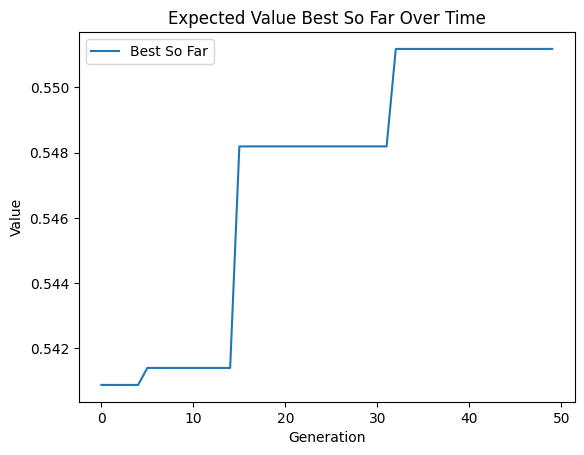

In [81]:
import json
import matplotlib.pyplot as plt

accs = []
evs = []
best_so_far = []  # 用來儲存每個世代中目前最好的值

# # 設定要顯示的最大代數
# max_generations = 50
# path_file = f"{path_out}/{start_day.strftime('%Y%m%d')}_{end_day.strftime('%Y%m%d')}_15pro/"
# path_file = f"{path_out}{stock_id}/20231001_202406302_1/"

print(results_file)
with open(results_file, 'r') as f:
    content = f.readlines()
    current_best = float('-inf')  # 初始化為最小值
    for i, line in enumerate(content):

        result = json.loads(line)
        acc = result['best_fitness']
        accs.append(acc)
        
        # 計算best so far
        if acc > current_best:
            current_best = acc
        best_so_far.append(current_best)

# 繪圖
# plt.plot(accs, label='Accuracy')
plt.plot(best_so_far, label='Best So Far')

plt.title('Expected Value Best So Far Over Time')  # 添加標題
plt.xlabel('Generation')  # X軸標籤
plt.ylabel('Value')  # Y軸標籤
plt.legend()  #


## 輸出判斷依據

In [153]:
# individual = [1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0]
individual = best_individual
for i in range(len(individual)):
    if individual[i] == 1:
        print(value_list[i])

股價波動率: 股價的波動幅度能夠顯示市場對企業的短期反應和投資風險。
財報發佈: 公司定期公佈的財務報告可以反映出企業的經營狀況，對股價有顯著影響。
價格移動平均線: 平滑短期價格波動，幫助判斷股票的中長期趨勢。
公司內部管理調整: 內部管理的調整會影響企業的運營效率和員工士氣。
外匯匯率波動: 外匯匯率變動對國際企業的財務表現和市場評估產生直接影響。
競爭者動作: 競爭對手的市場策略或行為變化可能直接影響公司股價表現。
業內消息與謠言: 業內消息或謠言可能會影響市場對企業的認知，進而影響股價。
國際經濟事件影響: 全球性經濟事件如貿易戰或金融危機，會影響國際企業的表現。
股東回報政策: 穩定的股東回報政策能增加投資者的持股意願，推動股價穩定上升。
銷售數據公佈: 銷售數據能反映公司產品需求狀況，對未來收益具有預示作用。
市場需求波動: 市場對公司產品或服務的需求波動會直接影響其業績和股價表現。
成本控制措施: 良好的成本控制可以提升利潤率，從而對股價有積極影響。
競爭對手行為分析: 競爭對手的產品定價、行銷策略等變動會改變公司競爭格局。
客戶需求變化: 客戶需求的快速變化會對公司產品策略和市場反應產生影響。
價格調整策略: 公司的價格調整策略會影響其產品市場定位，從而影響銷售和收益。
預測性財務數據: 預期的財務數據公佈可能會影響市場預期和股票交易活動。
新產品推出時間點: 新產品推出的時間和效果會影響市場對企業未來增長的信心。
股息分配調整: 股息政策的調整會影響投資者的投資決策和市場對公司前景的看法。
投資者信心波動: 投資者對公司未來表現的信心波動會直接反映在股價的波動上。
財務風險評估: 企業財務狀況的風險評估會影響投資者的持股意願和公司股價。
合作夥伴變動: 與合作夥伴的關係變化會影響公司的市場策略和業務發展。
品牌推廣活動: 品牌推廣能提升公司產品的市場認知度，促進銷售和股價表現。
財務報表修正: 財務報表的修正可能反映出之前數據的誤差，影響市場信心。
行業趨勢變化: 行業趨勢的變化會影響公司未來的戰略和市場定位。


## 計算使用的費用

In [196]:
# with open(path_out + '/2.json', 'r') as f:
#     content = f.read().strip()
#     data_points = json.loads(content)
# ske = data_points["output_data"]

# # print(ske) 
# print(len(ske))
# # Initialize counters
# total_input_tokens = 0
# total_output_tokens = 0
# total_tokens = 0

# # Loop through each date and each element within skeleton
# for date, date_data in ske.items():
#     for element, element_data in date_data["skeleton"].items():
#         total_input_tokens += element_data["token"]["input_tokens"]
#         total_output_tokens += element_data["token"]["output_tokens"]
#         total_tokens += element_data["token"]["total_tokens"]

# print("Total input tokens:", total_input_tokens)
# print("Total output tokens:", total_output_tokens)
# print("Total tokens:", total_tokens)


# print(f'預估費用 {(total_input_tokens/1000000)*0.15 + (total_output_tokens/1000000)*0.6} USD')